# Consumer Credit Risk — Probability of Default & Loan Decisioning
### German Credit data (`german_credit_data.csv`)

**Context.** A lender wants to decide, from an applicant's information, *how risky* a loan is — and act on it. We want to approve as many people without going over a reasonable loss threshold. With the assumption that a bad customer is 5x as bad as a good customer, we adjust our model to take this into account



In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
import seaborn as sns
RNG = np.random.RandomState(42)
plt.rcParams['figure.figsize'] = (7,4)

## 1. Load & define the target

`NA` in the account columns is read as missing **on purpose** — whether an applicant has an account on file turns out to be one of the most important signals (Insight 1). Target: `default = 1` when `Risk == 'bad'`.

In [41]:
df = pd.read_csv('../data/german_credit_data.csv', index_col=0,
                 keep_default_na=False, na_values=['NA'])
y = (df['Risk'] == 'bad').astype(int).values
X = df.drop(columns=['Risk']).copy()
print('shape:', df.shape, '| default rate:', round(y.mean(),3))
print('\nMissing values (a feature, not a defect):')
print(df.isna().sum())
df.head(3)
print(y)

shape: (1000, 10) | default rate: 0.3

Missing values (a feature, not a defect):
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64
[0 1 0 0 1 0 0 0 0 1 1 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 0 1
 0 1 0 1 0 1 1 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 1 1 1 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0
 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1
 0 0 0 0 0 1 1 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0

## 2. Data insights — the part that changes business decisions

Before modelling, three findings worth presenting on their own. Each is something the business can act on regardless of the model.

### Insight 1 — "No account on file" is the *lowest*-risk group, not the highest

Intuition says a missing checking account looks worse. The data says the opposite: applicants with **no checking account on file default at ~12%**, versus **~49% for those with a "little" balance**. The same pattern holds for savings. Practical consequence: **do not impute or drop these NAs**


In [43]:
def rate_by(col):
    c = df[col].fillna('(no account on file)')
    out = (pd.DataFrame({col:c,'default':y}).groupby(col)['default']
           .agg(default_rate='mean', n='size').sort_values('default_rate'))
    return out.round(3)

print(rate_by('Checking account'))


                      default_rate    n
Checking account                       
(no account on file)         0.117  394
rich                         0.222   63
moderate                     0.390  269
little                       0.493  274


SAVING ACCOUNTS
                      default_rate    n
Saving accounts                        
rich                         0.125   48
quite rich                   0.175   63
(no account on file)         0.175  183
moderate                     0.330  103
little                       0.360  603


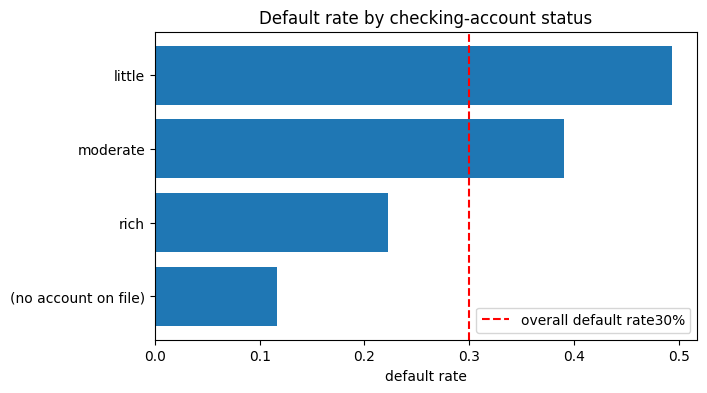

In [44]:
print('SAVING ACCOUNTS'); print(rate_by('Saving accounts'))

fig, ax = plt.subplots()
r = rate_by('Checking account')
ax.barh(r.index.astype(str), r['default_rate'])
ax.axvline(y.mean(), color='red', ls='--', label=f'overall default rate{y.mean():.0%}')
ax.set_xlabel('default rate')
ax.set_title('Default rate by checking-account status')
ax.legend()
plt.show()

### Insight 2 — Long-duration, large loans are the danger zone

Default climbs steadily with loan term — from ~21% at ≤12 months to ~52% beyond 36 months — and the largest-amount quartile defaults far more than the middle. The two combine: big loans stretched over long terms are where losses concentrate. This is a direct lever — **cap term/size in the high-risk corner** — that doesn't even require the model.

In [45]:
band = pd.cut(df['Duration'], [0,12,24,36,100], labels=['<=12','13-24','25-36','>36'])
by_dur = pd.DataFrame({'term':band,'default':y}).groupby('term',observed=True)['default'].agg(default_rate='mean', n='size')


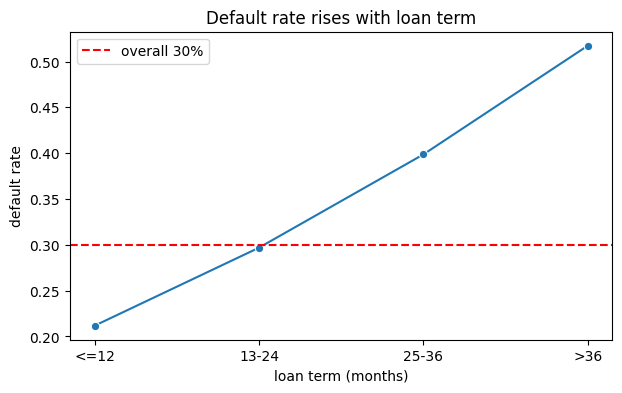

In [46]:
by_dur_r = by_dur.reset_index()

fig, ax = plt.subplots()
sns.lineplot(data=by_dur_r, x='term', y='default_rate', marker='o', ax=ax)
ax.axhline(y.mean(), color='red', ls='--', label=f'overall {y.mean():.0%}')
ax.set_xlabel('loan term (months)'); ax.set_ylabel('default rate')
ax.set_title('Default rate rises with loan term')
ax.legend()
plt.show()

### Insight 3 — The dataset is imbalanced, which dictates the metric

Only **30%** of loans default. So *accuracy is a trap*: a model that approves everyone is "70% accurate" and catches zero defaults. This is why the rest of the notebook evaluates probabilities with proper scoring rules and decides with a cost function — not accuracy.

## 3. Feature engineering & preprocessing

- Didn't filter out N/A values 
- Created an installment_burden filter

In [47]:
X['Saving accounts'] = X['Saving accounts'].fillna('none/unknown')
X['Checking account'] = X['Checking account'].fillna('none/unknown')
print(X)


     Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0     67    male    2     own    none/unknown           little           1169   
1     22  female    2     own          little         moderate           5951   
2     49    male    1     own          little     none/unknown           2096   
3     45    male    2    free          little           little           7882   
4     53    male    2    free          little           little           4870   
..   ...     ...  ...     ...             ...              ...            ...   
995   31  female    1     own          little     none/unknown           1736   
996   40    male    3     own          little           little           3857   
997   38    male    2     own          little     none/unknown            804   
998   23    male    2    free          little           little           1845   
999   27    male    2     own        moderate         moderate           4576   

     Duration              

In [48]:

X['Job'] = X['Job'].astype(str)
X['installment_burden'] = X['Credit amount'] / X['Duration']
print(X)
print(type(X['Job'].iloc[0]))

     Age     Sex Job Housing Saving accounts Checking account  Credit amount  \
0     67    male   2     own    none/unknown           little           1169   
1     22  female   2     own          little         moderate           5951   
2     49    male   1     own          little     none/unknown           2096   
3     45    male   2    free          little           little           7882   
4     53    male   2    free          little           little           4870   
..   ...     ...  ..     ...             ...              ...            ...   
995   31  female   1     own          little     none/unknown           1736   
996   40    male   3     own          little           little           3857   
997   38    male   2     own          little     none/unknown            804   
998   23    male   2    free          little           little           1845   
999   27    male   2     own        moderate         moderate           4576   

     Duration              Purpose  ins

In [49]:

num_cols = ['Age','Credit amount','Duration','installment_burden']
cat_cols = ['Sex','Job','Housing','Saving accounts','Checking account','Purpose']
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
print('features:', len(num_cols)+len(cat_cols))
print(num_cols)

features: 10
['Age', 'Credit amount', 'Duration', 'installment_burden']


## 4. Calibration-first model

**Design choice:** no class weighting. Reweighting distorts probabilities away from the true base rate, but calibrated PDs are the deliverable — so I keep probabilities honest and push the 5:1 cost asymmetry into the *decision threshold* (Section 6). Regularized logistic regression suits a small, regulated problem: resistant to overfitting, near-calibrated, and explainable. All PDs are produced out-of-fold via `cross_val_predict` (no leakage).

In [52]:
logit = Pipeline([('pre', preprocess),
                  ('clf', LogisticRegression(max_iter=2000, C=0.5))])
cv = StratifiedKFold(5, shuffle=True, random_state=42)
pd_hat = cross_val_predict(logit, X, y, cv=cv, method='predict_proba')[:,1]

acc = []
for i in range(len(pd_hat)):
    if pd_hat[i] < 0.5:
        val = 0
    else:
        val = 1
    if y[i] == val:
        acc.append(1)
    else:
        acc.append(0)

print("Default Accuracy", sum(acc)/len(acc))

Default Accuracy 0.735


## 5. Evaluation with proper scoring rules

Brier and log loss reward *honest probabilities*; accuracy rewards confident labels. AUC is shown only as a ranking check. (AUC here is modest — this is a 9-feature subset of the full 20-feature Statlog data, so some discrimination is left on the table. I'd flag that as a known limitation rather than hide it.)

In [53]:
print('AUC     = %.3f' % roc_auc_score(y, pd_hat))
print('Brier   = %.4f' % brier_score_loss(y, pd_hat))
print('LogLoss = %.4f' % log_loss(y, pd_hat))


AUC     = 0.744
Brier   = 0.1768
LogLoss = 0.5322


### Stability on a small sample

One train/test split on 1,000 rows is noisy, so I report the spread of Brier across folds — the variance is itself a result the business should know.

In [35]:
sc = cross_val_score(logit, X, y, scoring='neg_brier_score',
                     cv=StratifiedKFold(5, shuffle=True, random_state=1))
print('Brier per fold:', np.round(-sc,4))
print('Brier = %.4f ± %.4f' % (-sc.mean(), sc.std()))

Brier per fold: [0.1808 0.1647 0.1922 0.1745 0.1692]
Brier = 0.1763 ± 0.0096


## 6. From PD to decision — the 5:1 cost matrix

Approving a defaulter costs **5**; declining a good payer costs **1**. Minimizing expected cost, decline when
$$5\,p > 1\,(1-p)\;\Rightarrow\; p > \tfrac16 \approx 0.167.$$
The optimal cutoff is **0.167, not 0.5** — impossible to express with a binary model, and it cuts total cost substantially.

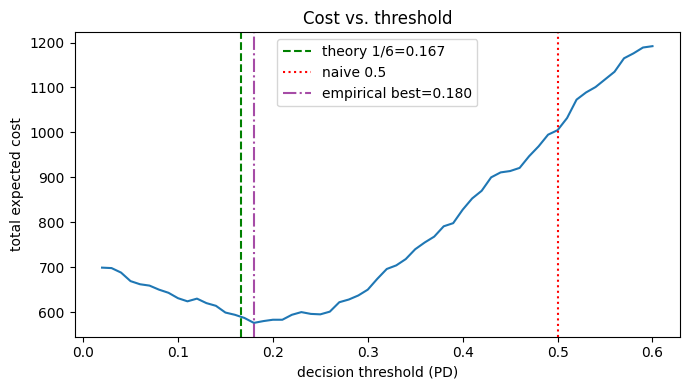

cost @0.5 = 1005 | cost @0.167 = 587 | reduction = 41.6%


In [36]:
C_FN, C_FP = 5.0, 1.0
thr_star = C_FP/(C_FP+C_FN)
def total_cost(p, thr):
    decline = p >= thr
    fn = np.sum((~decline) & (y==1)); fp = np.sum(decline & (y==0))
    return fn*C_FN + fp*C_FP

ts = np.linspace(0.02,0.6,59); costs=[total_cost(pd_hat,t) for t in ts]
emp = ts[int(np.argmin(costs))]
fig, ax = plt.subplots()
ax.plot(ts, costs)
ax.axvline(thr_star, color='green', ls='--', label=f'theory 1/6={thr_star:.3f}')
ax.axvline(0.5, color='red', ls=':', label='naive 0.5')
ax.axvline(emp, color='purple', ls='-.', alpha=.7, label=f'empirical best={emp:.3f}')
ax.set_xlabel('decision threshold (PD)'); ax.set_ylabel('total expected cost')
ax.set_title('Cost vs. threshold'); ax.legend(); plt.tight_layout(); plt.show()

base, opt = total_cost(pd_hat,0.5), total_cost(pd_hat,thr_star)
print('cost @0.5 = %.0f | cost @0.167 = %.0f | reduction = %.1f%%' %
      (base, opt, 100*(base-opt)/base))